# Comparison with ATLAS ITk Events in the presence of neutrals

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

from utils import load_config_data, get_hist_data, load_root_file

**Points of comparison**
For a specific configuration of the simulation (pt = 150MeV, eta = [-4, 4], with neutrals, with secondaries):
- For ITk, go back to the root file to get particle list (particularly, low pt and neutrals)
- How many target particles (be very explicit and apples to apples)
- How many target hits vs eta (theory that high eta in ITk is giving many target hits)
- How many background hits (low pt primary, or secondary) vs eta
- How many hits per target and background particle
- How many neutral hits per neutral particle in ODD?

## Load ODD Data

In [30]:
base_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison")
config_name = "config_pt100_postpt0.01_eta-4.0_4.0_neutralsFalse_secondariesTrue"
odd_hits, odd_particles, odd_pythia = load_config_data(base_dir, config_name)

100%|██████████| 32/32 [00:18<00:00,  1.74it/s]


In [35]:
file_path = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison/odd_output_config_pt100_postpt0_eta-4.0_4.0_neutralsFalse_secondariesTruePU400"
odd_hits = load_root_file(f"{file_path}/hits.root", event_id=0)
odd_particles = load_root_file(f"{file_path}/particles_simulation.root", event_id=0)

# # Get the number of hits
# # First, count number of hits per particle and give it a name
# num_hits_per_particle = odd_hits.groupby("particle_id").size().to_frame("num_hits")

# # Merge with particles df
# odd_particles = odd_particles.merge(num_hits_per_particle, left_on="particle_id", right_index=True, suffixes=["", "_hits"])
# odd_particles["number_of_hits"] = odd_particles["num_hits"]


In [36]:
# Create masks for each condition
target_mask = (
    (odd_particles.vertex_secondary == 0) &
    (odd_particles.q != 0) &
    (odd_particles.pt > 1) &
    (odd_particles.number_of_hits >= 1)
)

background_mask = (
    (odd_particles.q != 0) &
    (
        (odd_particles.pt < 1) |
        (odd_particles.vertex_secondary != 0)
    ) &
    (odd_particles.number_of_hits >= 1)
)

neutral_mask = (
    (odd_particles.q == 0) &
    (odd_particles.number_of_hits >= 1)
)

target_particles = odd_particles[target_mask]
background_particles = odd_particles[background_mask]
neutral_particles = odd_particles[neutral_mask]
noise_particles = odd_particles[~target_mask & ~background_mask & ~neutral_mask]

# Calculate statistics
n_events = len(odd_particles.event_id.unique())
print(f"Total particles per event: {len(odd_particles) / n_events:.2f}")
print(f"Target particles per event: {len(target_particles) / n_events:.2f}")
print(f"Background particles per event: {len(background_particles) / n_events:.2f}")
print(f"Neutral particles per event: {len(neutral_particles) / n_events:.2f}")
print(f"Noise particles per event: {len(noise_particles) / n_events:.2f}")

Total particles per event: 55736.00
Target particles per event: 1959.00
Background particles per event: 53777.00
Neutral particles per event: 0.00
Noise particles per event: 0.00


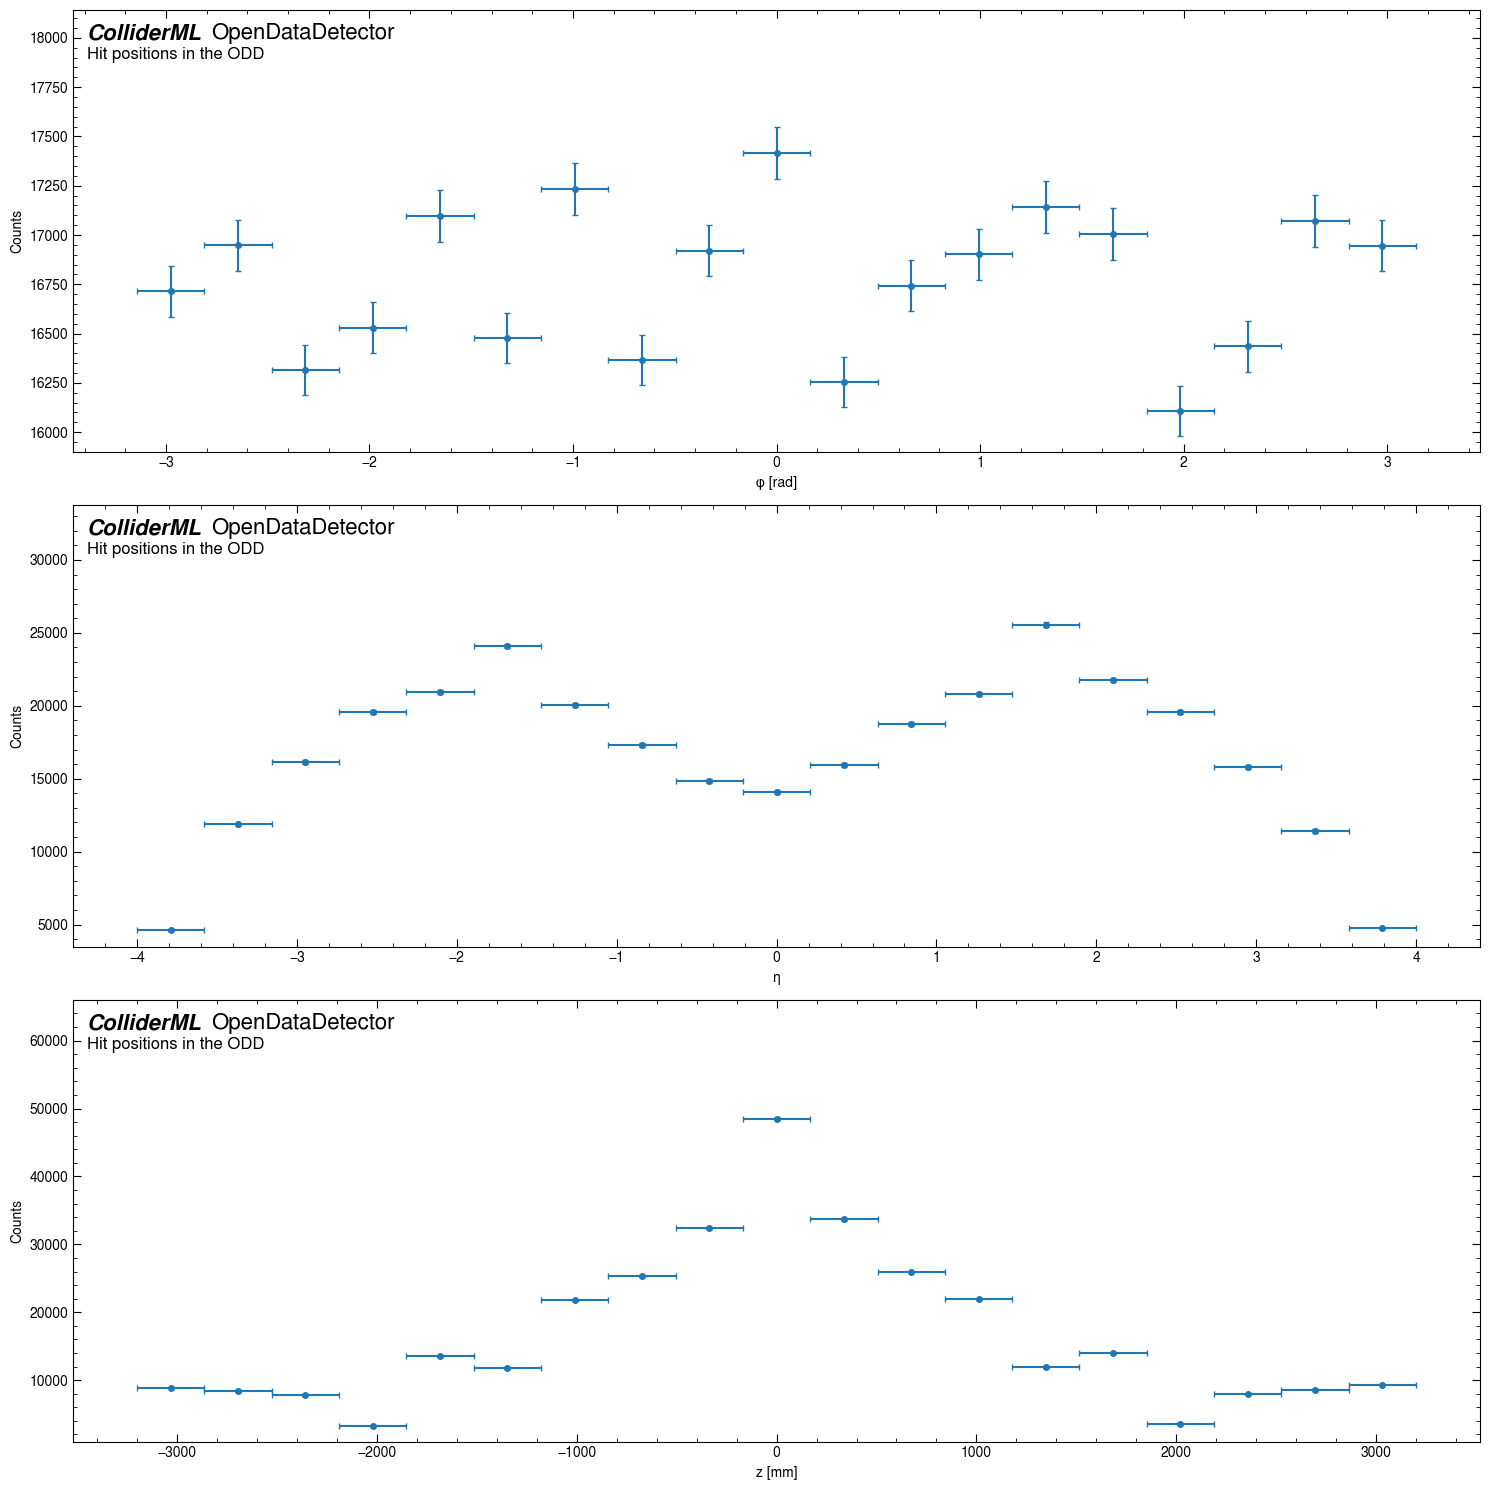

In [37]:
# First check the intermediate values
odd_hits["r"] = np.sqrt(odd_hits.tx**2 + odd_hits.ty**2)
odd_hits["phi"] = np.arctan2(odd_hits.ty, odd_hits.tx)

# Modified theta calculation to handle edge cases
odd_hits["theta"] = np.arctan2(np.sqrt(odd_hits.tx**2 + odd_hits.ty**2), odd_hits.tz)

# More robust eta calculation
odd_hits["eta"] = -np.log(np.tan(odd_hits.theta/2 + 1e-10))  # Add small epsilon to avoid exact 0/π

r_centers, r_counts, r_widths, r_errors = get_hist_data(odd_hits.r, np.linspace(0, 1200, 20), odd_hits.event_id)
phi_centers, phi_counts, phi_widths, phi_errors = get_hist_data(odd_hits.phi, np.linspace(-np.pi, np.pi, 20), odd_hits.event_id)
eta_centers, eta_counts, eta_widths, eta_errors = get_hist_data(odd_hits.eta, np.linspace(-4, 4, 20), odd_hits.event_id)
z_centers, z_counts, z_widths, z_errors = get_hist_data(odd_hits.tz, np.linspace(-3200, 3200, 20), odd_hits.event_id)

fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs[0].errorbar(phi_centers, phi_counts, yerr=phi_errors, xerr=phi_widths, 
            fmt='o', label='phi', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[0])
axs[0].set_xlabel("φ [rad]")
axs[0].set_ylabel("Counts")

axs[1].errorbar(eta_centers, eta_counts, yerr=eta_errors, xerr=eta_widths, 
            fmt='o', label='eta', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[1])
axs[1].set_xlabel("η")
axs[1].set_ylabel("Counts")

axs[2].errorbar(z_centers, z_counts, yerr=z_errors, xerr=z_widths, 
            fmt='o', label='z', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[2])
axs[2].set_xlabel("z [mm]")
axs[2].set_ylabel("Counts")

plt.tight_layout()
plt.show()

In [38]:
odd_hits = odd_hits.drop(columns=["index"])
odd_hits["hit_id"] = odd_hits.index

# Merge hits to target particles on both particle_id and event_id
target_hits = odd_hits.merge(target_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
background_hits = odd_hits.merge(background_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
neutral_hits = odd_hits.merge(neutral_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])

# Now we can safely use pandas index for the noise hits identification
noise_hits = odd_hits[~odd_hits.hit_id.isin(target_hits.hit_id) & 
                     ~odd_hits.hit_id.isin(background_hits.hit_id) & 
                     ~odd_hits.hit_id.isin(neutral_hits.hit_id)]

print(f"Total hits per event: {len(odd_hits) / n_events:.2f}")
print(f"Target hits per event: {len(target_hits) / n_events:.2f}")
print(f"Background hits per event: {len(background_hits) / n_events:.2f}")
print(f"Neutral hits per event: {len(neutral_hits) / n_events:.2f}")
print(f"Noise hits per event: {len(noise_hits) / n_events:.2f}")

Total hits per event: 318618.00
Target hits per event: 22008.00
Background hits per event: 296390.00
Neutral hits per event: 0.00
Noise hits per event: 220.00


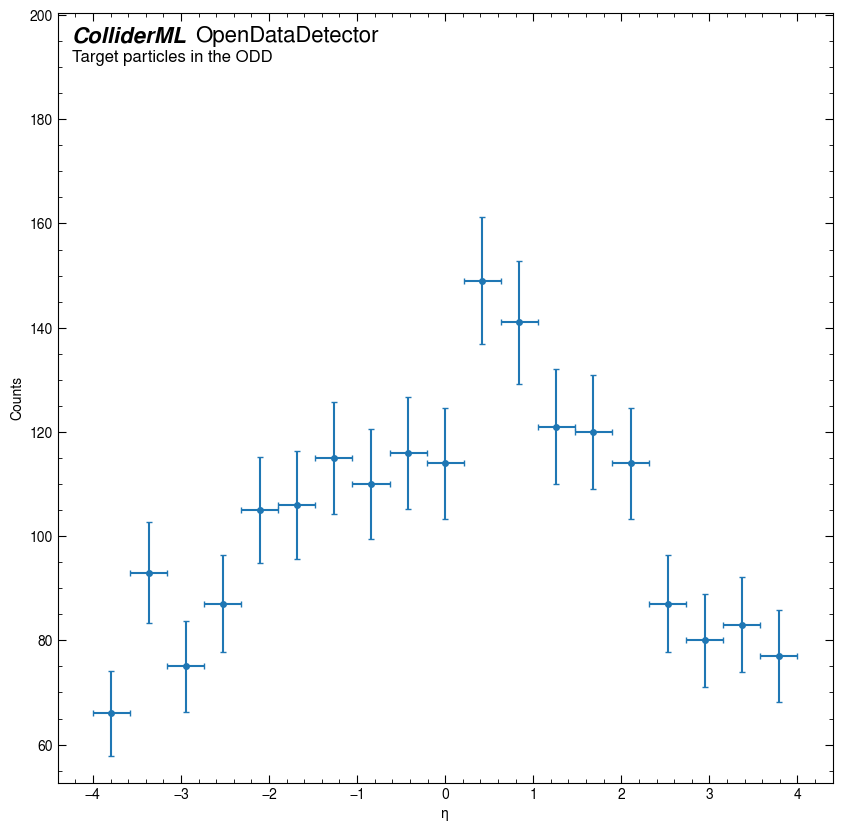

In [39]:
target_eta_centers, target_eta_counts, target_eta_widths, target_eta_errors = get_hist_data(target_particles.eta, np.linspace(-4, 4, 20), target_particles.event_id)
plt.figure(figsize=(10, 10))
plt.errorbar(target_eta_centers, target_eta_counts, yerr=target_eta_errors, xerr=target_eta_widths, 
            fmt='o', label='Target', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Target particles in the ODD", axes=plt.gca())
plt.xlabel("η")
plt.ylabel("Counts")
plt.show()


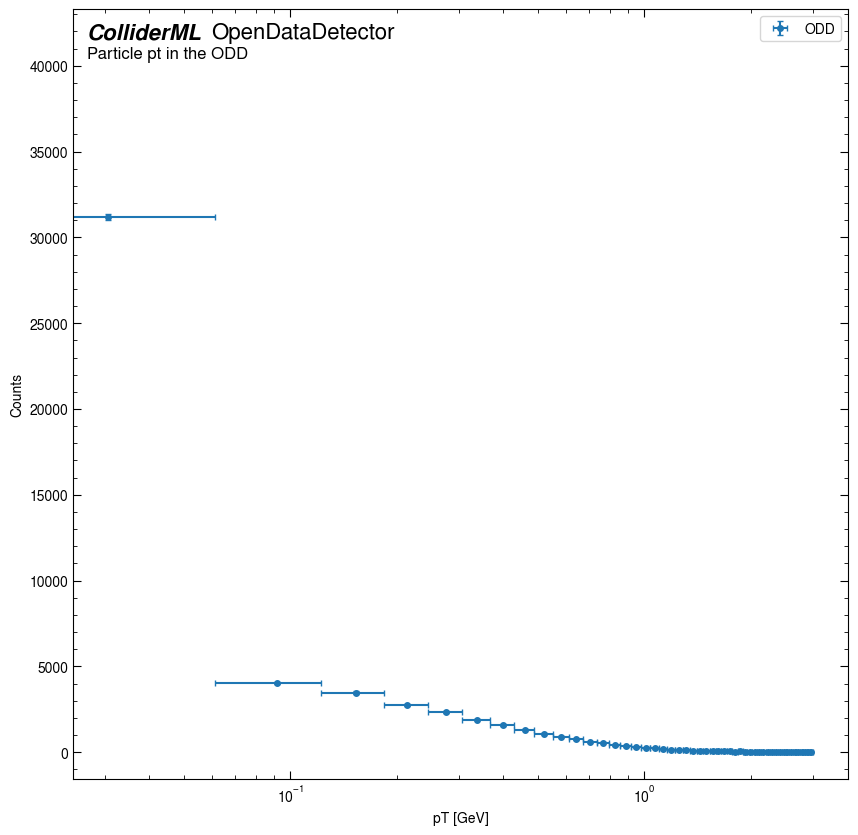

In [40]:
odd_pt_centers, odd_pt_counts, odd_pt_widths, odd_pt_errors = get_hist_data(odd_particles.pt, np.linspace(0, 3, 50), odd_particles.event_id)

plt.figure(figsize=(10, 10))
plt.errorbar(odd_pt_centers, odd_pt_counts, yerr=odd_pt_errors, xerr=odd_pt_widths, 
            fmt='o', label='ODD', markersize=4, capsize=2)
plt.xlabel("pT [GeV]")
plt.ylabel("Counts")
# x axis is log scale
plt.xscale("log")
atl.atlasify("OpenDataDetector", "Particle pt in the ODD", axes=plt.gca())
plt.legend()
plt.show()